In [1]:
import pandas as pd
import numpy as np
import random
months = ["2025-01","2025-02","2025-03","2025-04","2025-05","2025-06","2025-07","2025-08","2025-09","2025-10","2025-11","2025-12"]
categories = ["Sports", "Beauty","Clothing"]
regions = {
    "North": 13,
    "South": 12,
    "West": 11,
    "East": 14
}

In [2]:
#Sales rep id generation

sales_reps = []
for region, count in regions.items():
    prefix = region[:3].upper()
    for i in range(1, count + 1):
        rep_id = prefix + "23" + str(i).zfill(3)
        sales_reps.append((rep_id, region))
#Data generation

data=[]
for rep_id, region in sales_reps:
    for month in months:
        for category in categories:
            revenue = np.random.randint(20000,120000)
            target = np.random.randint(50000,100000)
            data.append({
                "sales_rep_id": rep_id,
                "region": region,
                "month": month,
                "product_category": category,
                "revenue": revenue,
                "target": target
            })

In [4]:
#Convert to DataFrame and save
df = pd.DataFrame(data)
df.shape
df.head()
df.to_csv("../data/raw/sales_data.csv", index=False)

In [5]:
# Basic analysis
df["achievement_pct"] = df["revenue"] / df["target"]
df.head()
df["achievement_pct"].describe()

count    1800.000000
mean        0.968605
std         0.456134
min         0.205631
25%         0.594467
50%         0.932894
75%         1.268290
max         2.380847
Name: achievement_pct, dtype: float64

In [6]:
# Commission rate calculation
df["commission_rate"]=0.0
df.loc[df["achievement_pct"]<0.7,"commission_rate"]=0.02
mask = (df["achievement_pct"] >= 0.7) & (df["achievement_pct"] <= 1)

df.loc[mask, "commission_rate"] = 0.03 + (
    (df.loc[mask, "achievement_pct"] - 0.7) * (0.02 / 0.3)
)
mask = df["achievement_pct"] > 1
df.loc[mask, "commission_rate"] = 0.05 + (
    (df.loc[mask, "achievement_pct"] - 1) * 0.1
)

#Payout calculation
df["incentive_payout"] = df["revenue"] * df["commission_rate"]
df[["achievement_pct","commission_rate","incentive_payout"]].head(10)

,achievement_pct,commission_rate,incentive_payout
0,1.109372,0.060937,6177.817749
1,0.742909,0.032861,1476.852813
2,1.121628,0.062163,6866.435446
3,0.902549,0.043503,2022.596978
4,1.315155,0.081515,9412.101322
5,1.174942,0.067494,7795.914846
6,1.024952,0.052495,2805.446200
7,1.247036,0.074704,8477.286212
8,1.007646,0.050765,2589.045904
9,0.514442,0.020000,1016.600000


In [7]:
df.groupby("region")["revenue"].sum().sort_values(ascending=False)#revenue by region
df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)#revenue by product category
df.groupby("month")["revenue"].sum()#monthly sales trend

#top 10 sales reps by revenue
(
    df.groupby("sales_rep_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

df["incentive_payout"].sum()#Incentive cost
df.groupby("region")["incentive_payout"].sum()#incentive cost by region
#saving the final dataset
df.to_csv("../data/processed/sales_performance_final.csv", index=False)

In [ ]:
#Checking for data quality
df.isnull().sum()
df.duplicated().sum()
df.dtypes
df[df["revenue"] < 0]
df.shape
#Saving cleaned dataset
#df.to_csv("../data/processed/sales_performance_cleaned.csv", index=False)


## Sales Performance visualization

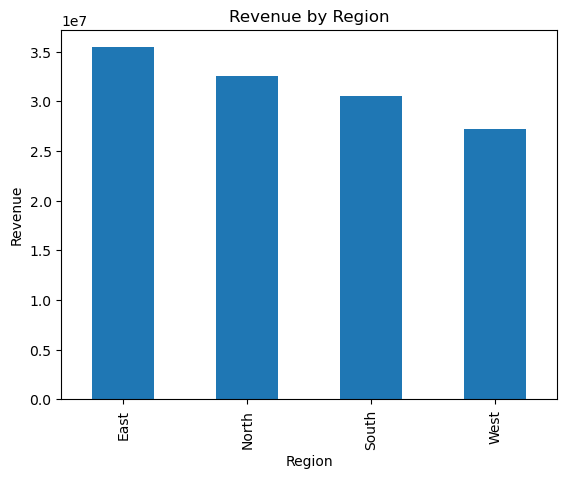

In [9]:
import matplotlib.pyplot as plt

#Revenue by region
df.groupby("region")["revenue"].sum().plot(kind="bar")

plt.title("Revenue by Region")
plt.ylabel("Revenue")
plt.xlabel("Region")

plt.show()

Text(0.5, 0, 'Product Category')

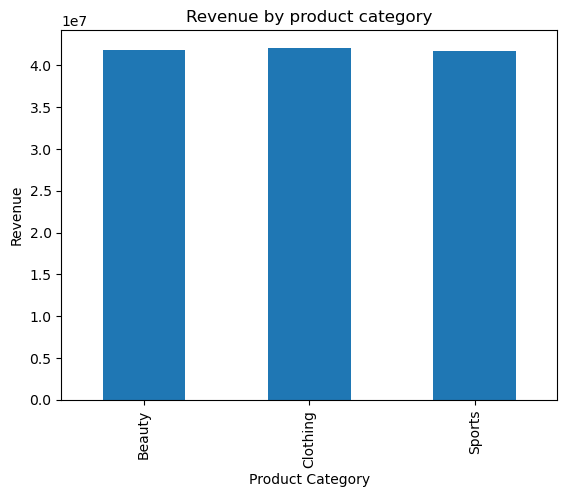

In [10]:
#revenue by product category
df.groupby("product_category")["revenue"].sum().plot(kind="bar")
plt.title("Revenue by product category")
plt.ylabel("Revenue")
plt.xlabel("Product Category")

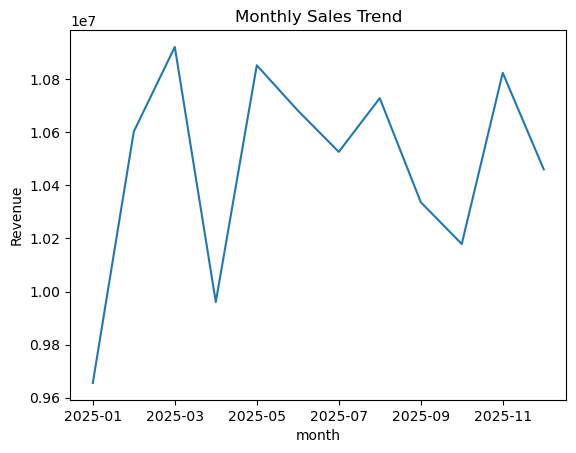

In [11]:
#Monthly sales trend
df.groupby("month")["revenue"].sum().plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()

## Sales Forecasting

In [14]:
monthly_sales = df.groupby("month")["revenue"].sum().reset_index()
## Converting months to numbers
monthly_sales["month_num"] = range(1, len(monthly_sales) + 1)

monthly_sales

,month,revenue,month_num
0,2025-01,9655693,1
1,2025-02,10602395,2
2,2025-03,10921192,3
3,2025-04,9960680,4
4,2025-05,10851993,5
5,2025-06,10681692,6
6,2025-07,10525863,7
7,2025-08,10728216,8
8,2025-09,10336617,9
9,2025-10,10178976,10


In [15]:
## Applying regression
from sklearn.linear_model import LinearRegression
X = monthly_sales[["month_num"]]
y = monthly_sales["revenue"]

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
##Predicting next month revenue
next_month=[[13]]
predicted_revenue = model.predict(next_month)
predicted_revenue

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([10636339.10606061])

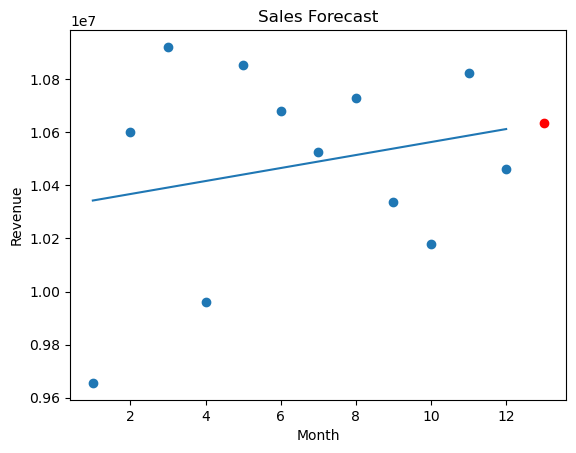

In [18]:
#visualizing regression line
import matplotlib.pyplot as plt

plt.scatter(monthly_sales["month_num"], monthly_sales["revenue"])

plt.plot(monthly_sales["month_num"], model.predict(X))

plt.scatter(13, predicted_revenue, color="red")

plt.title("Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

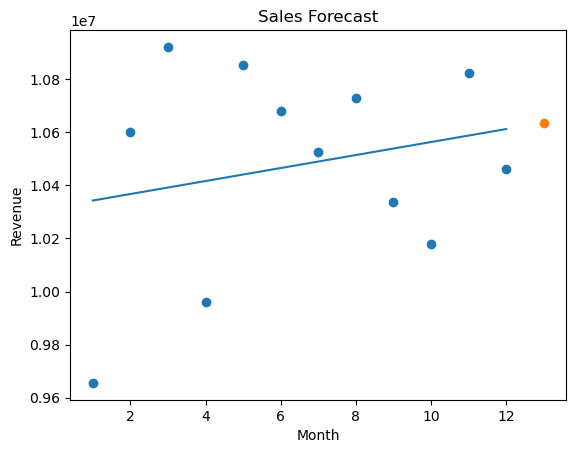

In [19]:
plt.scatter(monthly_sales["month_num"], monthly_sales["revenue"])
plt.plot(monthly_sales["month_num"], model.predict(X))
plt.scatter(13, predicted_revenue)

plt.title("Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.savefig("../reports/sales_forecast.png", bbox_inches="tight", dpi=200)
plt.show()